This notebook will load in existing models and run them without training them. 

In [1]:
import pandas as pd
import time
from notebook_logging_setup import quick_setup
from gymnasium.utils.env_checker import check_env
from stable_baselines3 import PPO
from gymnasium.wrappers import TimeLimit
import torch
import numpy as np
import random
import gc

# my libraries
from mkt_data_yfinance import MarketDataLoader as mdl
import render_plots as rp
import model_parking as mp
from optimal_execution_env_vectorized import VectorizedMultiOrderExecutionEnv
from vectorized_env_wrapper import create_vectorized_env
from order_generator import OrderGenerator
import baseline_strategies as bs
import gpu_utils

quick_setup(debug=False)
fixed_seed = 42
np.random.seed(fixed_seed)
random.seed(fixed_seed)  # Also seed the random module
num_vec_envs = 8

device = gpu_utils.get_torch_device()
gpu_utils.set_random_seed(fixed_seed)

print(f"Using device: {device}")
print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB" if device == 'cuda' else "")
print(f"MPS Available: {torch.backends.mps.is_available()}" if device == 'mps' else "")

Logging configured at INFO level
2025-07-15 23:07:11 - root - INFO - Using Apple Metal Performance Shaders (MPS)
Using device: mps

MPS Available: True


In [2]:
# Vectorized environment configuration
max_trading_rate = 0.8
max_order_size_in_adv_pct = 0.1

# Stock selection - optimized for vectorized processing
tickers = ['AAPL','MSFT','GOOGL','AMZN','TSLA','NVDA','JPM','V','JNJ','DIS', 
           'NKE', 'PYPL', 'ADBE', 'NFLX', 'INTC', 'CMCSA', 'PEP', 'MRK', 'VZ', 'T']

# Load market data with progress tracking
print("\nLoading market data...")
start_time = time.time()
md = mdl()
stock_df_list = md.load_data(tickers, horizon='7d')
stock_df_list = md.pre_process_data(stock_df_list)
load_time = time.time() - start_time
print(f"Data loaded in {load_time:.2f} seconds")

# Check available dates
sample_df = stock_df_list[list(stock_df_list.keys())[0]]
dates = pd.to_datetime(sample_df.index.date).unique()
print(f"Available dates: {len(dates)} days from {dates[0]} to {dates[-1]}")


Loading market data...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Data loaded in 7.58 seconds
Available dates: 7 days from 2025-07-07 00:00:00 to 2025-07-15 00:00:00


In [3]:
# Create train/test split using date filtering with larger batches for vectorized processing
print("Generating test orders...")
start_time = time.time()

# Test set: last 2 days (exclude first 5 days) - larger batch for vectorized processing
test_orders_df = OrderGenerator(
    stock_df_list=stock_df_list, 
    market_data=md, 
    debug=False, 
    max_adv_pct=max_order_size_in_adv_pct, 
    num_orders=50000,  # Increased for vectorized processing
    sd_delta=3,  # Skip first 5 days
    ed_delta=0,   # Include up to last day
    seed=fixed_seed
).get_orders()

test_time = time.time() - start_time
print(f"Test orders generated in {test_time:.2f} seconds")

# Verify the date split
print(f"\nTest set: {len(test_orders_df)} orders")
print(f"Test dates: {test_orders_df['date'].min()} to {test_orders_df['date'].max()}")
print(f"Orders per day (test):\n{test_orders_df['date'].value_counts().sort_index()}")

Generating test orders...
Test orders generated in 55.19 seconds

Test set: 50000 orders
Test dates: 2025-07-10 00:00:00 to 2025-07-15 00:00:00
Orders per day (test):
date
2025-07-10    12500
2025-07-11    12500
2025-07-14    12500
2025-07-15    12500
Name: count, dtype: int64


3 Sample Test Orders:
Sample Test (1): ticker: ADBE order_qty: 36197 adv_pct: 1.25% ehv_pct: 4.68% adv: 2,898,392 date: 2025-07-10 00:00:00 start_time: 270 end_time: 374 time_horizon: 104 side: sell intra_order_return: -0.003477717051282525 today_volatility: 0.02185983955860138 
Sample Test (2): ticker: AAPL order_qty: 318096 adv_pct: 0.92% ehv_pct: 3.31% adv: 34,720,236 date: 2025-07-10 00:00:00 start_time: 71 end_time: 179 time_horizon: 108 side: buy intra_order_return: -0.004928897600620985 today_volatility: 0.015990866348147392 
Sample Test (3): ticker: NVDA order_qty: 360147 adv_pct: 0.23% ehv_pct: 0.48% adv: 153,853,408 date: 2025-07-10 00:00:00 start_time: 20 end_time: 210 time_horizon: 190 side: buy intra_order_return: -0.0006732189212925732 today_volatility: 0.017820710316300392 


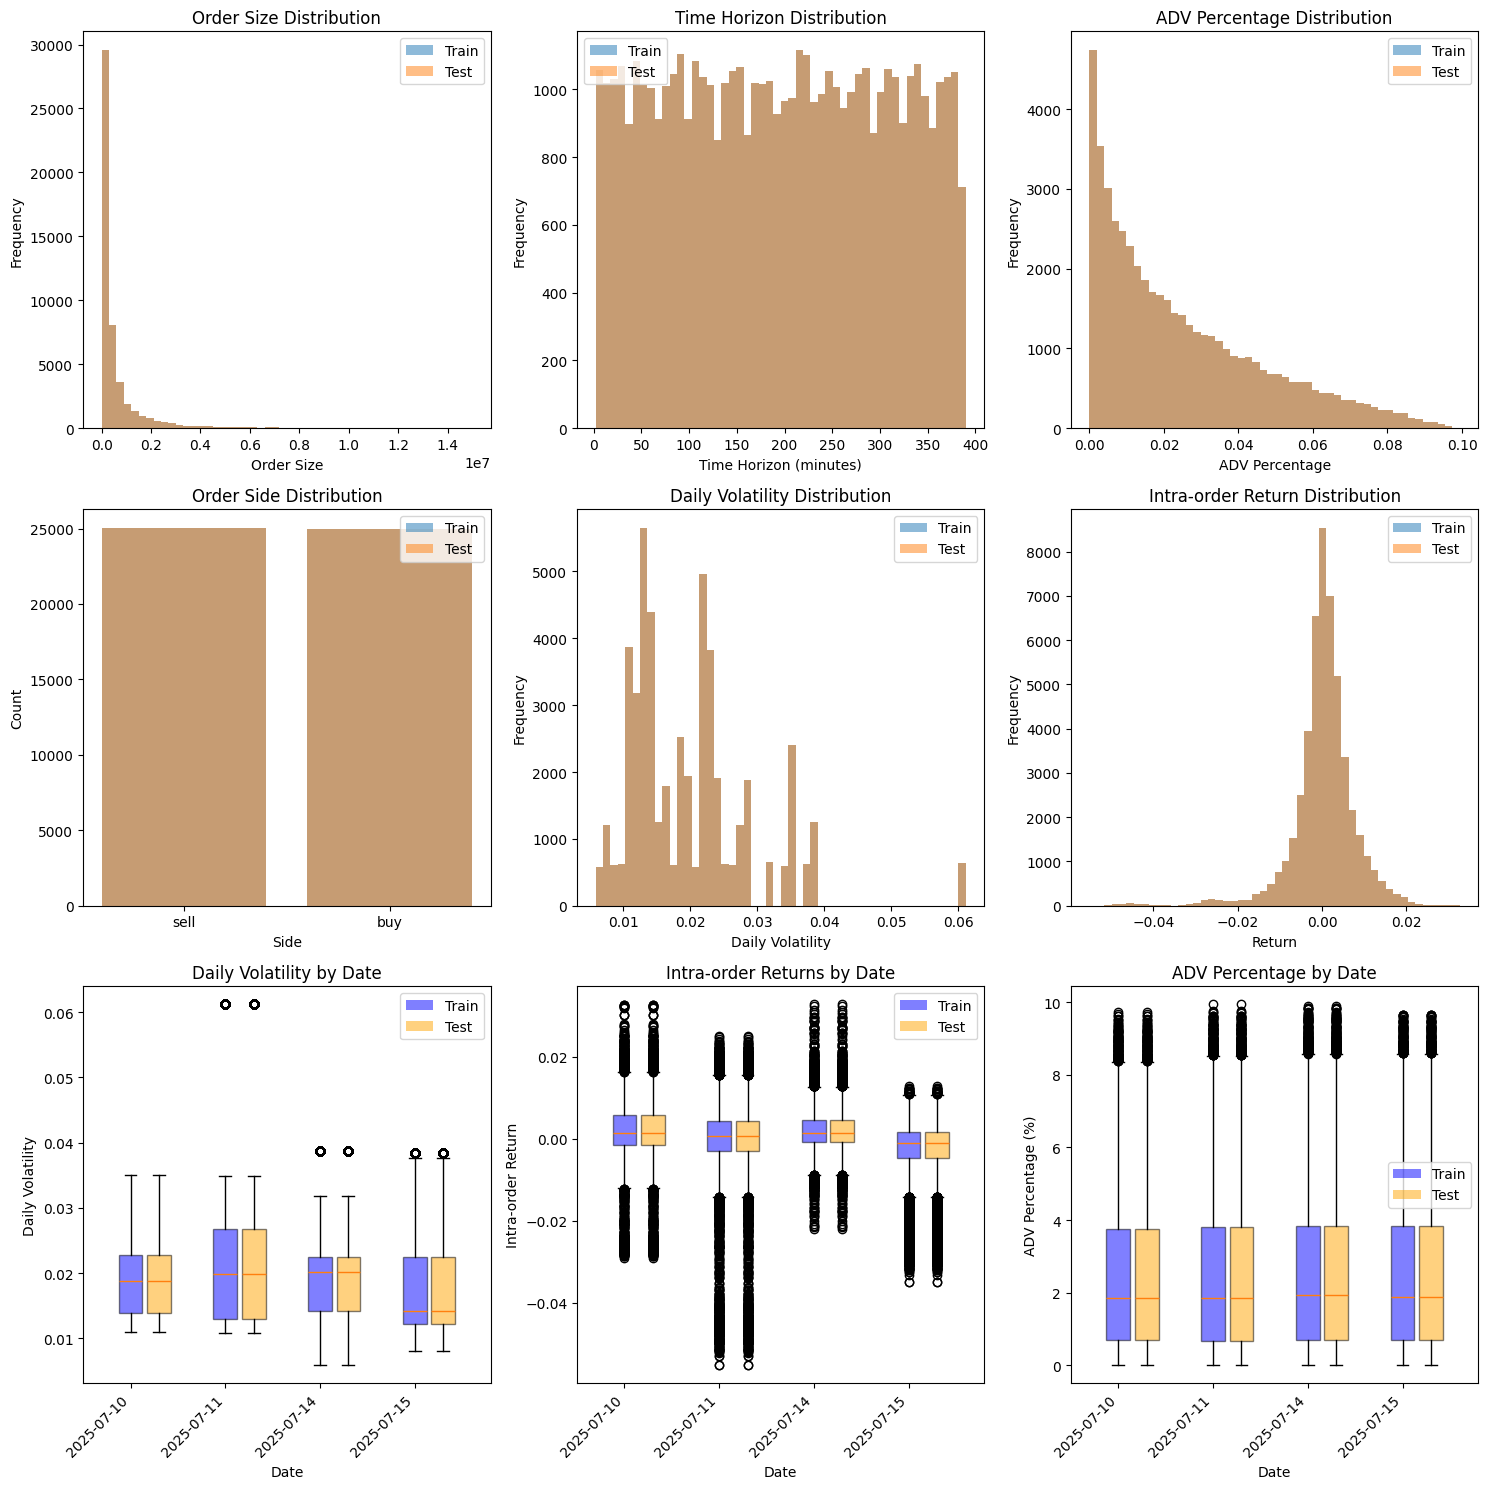


Sample test orders with dates:
  ticker       date  start_time  end_time  order_qty  side
0   ADBE 2025-07-10         270       374      36197  sell
1   AAPL 2025-07-10          71       179     318096   buy
2   NVDA 2025-07-10          20       210     360147   buy
3   TSLA 2025-07-10         121       225    2004999   buy
4   INTC 2025-07-10          74       290    1367220   buy


In [ ]:
# print orders dataframe in single line per order
rp.display_order_info(test_orders_df, name='Sample Test', num_orders=3)
rp.plot_order_histograms(a_df=test_orders_df, a_name='Test Orders')

# Show sample orders with dates
print("\nSample test orders with dates:")
print(test_orders_df[['ticker', 'date', 'start_time', 'end_time', 'order_qty', 'side']].head(5))

In [5]:
# Create vectorized execution environments for testing (direct access for execution)
print("\nCreating vectorized cpu test environment...")

test_cpu_env = create_vectorized_env(
    stock_df_list=stock_df_list, 
    orders_df=test_orders_df, 
    impact_coef=1, 
    num_envs=num_vec_envs,  # Vectorized environments
    decay_rate=5, 
    window_size=1, 
    min_rate=0, 
    max_rate=max_trading_rate,
    device="cpu",  
    seed=fixed_seed
)

check_env(test_cpu_env)
print("✓ Vectorized cpu test environment check passed!")

# for compatibility with training environment, create a GPU (if available) and CPU environment
if device in ["cuda", "mps"]:
    print("\nCreating vectorized gpu test environment...") 
    test_gpu_env = create_vectorized_env(
        stock_df_list=stock_df_list, 
        orders_df=test_orders_df, 
        impact_coef=1, 
        num_envs=num_vec_envs,  # Vectorized environments
        decay_rate=5, 
        window_size=1, 
        min_rate=0, 
        max_rate=max_trading_rate,
        device=device,  # Use GPU if available
        seed=fixed_seed
    )
    check_env(test_gpu_env)
    print("✓ Vectorized gpu test environment check passed!")

else:
    print("No GPU available, using CPU for training and testing")
    test_gpu_env = test_cpu_env
    test_execution_gpu_env = test_cpu_env


print(f"\nVectorized Environment Summary:")
print(f"  - Test orders: {len(test_orders_df)}")
print(f"  - Vectorized environments: {num_vec_envs}")
if device in ["cuda", "mps"]:
    print(f"  - Device: {device} + CPU")
else:
    print(f"  - Device: cpu")



Creating vectorized cpu test environment...
2025-07-15 23:08:16 - optimal_execution_env_vectorized - INFO - Using device: cpu (explicitly set)
✓ Vectorized cpu test environment check passed!

Creating vectorized gpu test environment...
2025-07-15 23:08:16 - optimal_execution_env_vectorized - INFO - Using device: mps (explicitly set)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/gymnasium/utils/env_checker.py:276: UserWarning: WARN: Official support for the `seed` function is dropped. Standard practice is to reset gymnasium environments using `env.reset(seed=<desired seed>)`
  logger.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/gymnasium/utils/env_checker.py:434: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


✓ Vectorized gpu test environment check passed!

Vectorized Environment Summary:
  - Test orders: 50000
  - Vectorized environments: 8
  - Device: mps + CPU


In [6]:
mp = mp.ModelParking(cached=True, env=test_cpu_env)
models = mp.list_models()
print("Available models:")
for model in models:
    print(model)

2025-07-15 23:08:17 - root - INFO - ModelParking initialized with cached models.
== CURRENT SYSTEM INFO ==
- OS: macOS-15.5-arm64-arm-64bit Darwin Kernel Version 24.5.0: Tue Apr 22 19:54:49 PDT 2025; root:xnu-11417.121.6~2/RELEASE_ARM64_T6000
- Python: 3.11.7
- Stable-Baselines3: 2.6.0
- PyTorch: 2.4.1
- GPU Enabled: False
- Numpy: 1.26.4
- Cloudpickle: 3.0.0
- Gymnasium: 1.1.1
- OpenAI Gym: 0.25.2

== SAVED MODEL SYSTEM INFO ==
- OS: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39 # 1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025
- Python: 3.12.3
- Stable-Baselines3: 2.6.0
- PyTorch: 2.5.1+cu121
- GPU Enabled: True
- Numpy: 2.1.3
- Cloudpickle: 3.1.1
- Gymnasium: 1.1.1

2025-07-15 23:08:18 - root - ERROR - Failed to load model 'ppo_cnn_multiorder_exec_vec': No module named 'numpy._core.numeric'
== CURRENT SYSTEM INFO ==
- OS: macOS-15.5-arm64-arm-64bit Darwin Kernel Version 24.5.0: Tue Apr 22 19:54:49 PDT 2025; root:xnu-11417.121.6~2/RELEASE_ARM64_T6000
- Python: 3.11.